# Decision Tree vs Random Forest

**Veri:** Telco-Customer-Churn.csv (7.043 müşteri, 21 değişken)
**Hedef:** `Churn` — müşterinin abonelikten ayrılıp ayrılmayacağı

## 1. Kütüphaneler

In [1]:
import sys, platform, hashlib, random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
print(f"Python: {sys.version.split()[0]} | Platform: {platform.platform()}")

Python: 3.9.6 | Platform: macOS-15.6-arm64-arm-64bit


## 2. Veri Setinin Yüklenmesi ve Keşfi

In [3]:
CSV_YOLU = "Telco-Customer-Churn.csv"
HEDEF    = "Churn"

def file_hash(path):
    # Veri versiyonlama için MD5 hash üretir.
    return hashlib.md5(open(path, "rb").read()).hexdigest()

df = pd.read_csv(CSV_YOLU).copy()
print(f"Veri: {CSV_YOLU} | Hash (MD5): {file_hash(CSV_YOLU)}")
assert HEDEF in df.columns, f"'{HEDEF}' sütunu bulunamadı: {list(df.columns)}"

print(f"Gözlem sayısı: {len(df)} | Değişken sayısı: {df.shape[1]}")
df.head()

Veri: Telco-Customer-Churn.csv | Hash (MD5): 3b0bfab28a8101b4e4fdd08025a5c235
Gözlem sayısı: 7043 | Değişken sayısı: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("🔢 Sütunlar, veri tipleri ve benzersiz değer sayıları:")
print(f"{'Sütun':<20} {'Tip':<12} {'Benzersiz':>10}")
print("─" * 45)
for col in df.columns:
    print(f"{col:<20} {str(df[col].dtype):<12} {df[col].nunique():>10}")

🔢 Sütunlar, veri tipleri ve benzersiz değer sayıları:
Sütun                Tip           Benzersiz
─────────────────────────────────────────────
customerID           object             7043
gender               object                2
SeniorCitizen        int64                 2
Partner              object                2
Dependents           object                2
tenure               int64                73
PhoneService         object                2
MultipleLines        object                3
InternetService      object                3
OnlineSecurity       object                3
OnlineBackup         object                3
DeviceProtection     object                3
TechSupport          object                3
StreamingTV          object                3
StreamingMovies      object                3
Contract             object                3
PaperlessBilling     object                2
PaymentMethod        object                4
MonthlyCharges       float64            1585


In [5]:
print("📊 İstatistiksel Özet (sayısal sütunlar):")
print(df.describe().T.round(3).to_string())

📊 İstatistiksel Özet (sayısal sütunlar):
                 count    mean     std    min   25%    50%    75%     max
SeniorCitizen   7043.0   0.162   0.369   0.00   0.0   0.00   0.00    1.00
tenure          7043.0  32.371  24.559   0.00   9.0  29.00  55.00   72.00
MonthlyCharges  7043.0  64.762  30.090  18.25  35.5  70.35  89.85  118.75


### 2.1 Sütun Yapısı Kontrolü

`customerID` 7043 benzersiz değer içeriyor (kimlik sütunu). `TotalCharges` metin tipinde — yeni müşterilerin toplam ödemesi boş karakter olarak kaydedildiği için. İkisi de düzeltilmezse `get_dummies` her ikisini de kategorik sanıp one-hot kodluyor.

In [6]:
print("customerID örnekleri:", df['customerID'].head(3).tolist())
print(f"customerID benzersiz oranı: {df['customerID'].nunique() / len(df) * 100:.1f}%")
print()
print("TotalCharges tipi:", df['TotalCharges'].dtype)
bos_satirlar = (df['TotalCharges'].astype(str).str.strip() == '').sum()
print(f"TotalCharges'da boş karakter içeren satır: {bos_satirlar}")
print()
print("Bu satırlardaki tenure değerleri:")
print(df.loc[df['TotalCharges'].astype(str).str.strip() == '', 'tenure'].value_counts().to_string())
print("→ Hepsi tenure=0, yani hiç fatura kesilmemiş yeni müşteriler. Mantıklı bir eksiklik.")

customerID örnekleri: ['7590-VHVEG', '5575-GNVDE', '3668-QPYBK']
customerID benzersiz oranı: 100.0%

TotalCharges tipi: object
TotalCharges'da boş karakter içeren satır: 11

Bu satırlardaki tenure değerleri:
tenure
0    11
→ Hepsi tenure=0, yani hiç fatura kesilmemiş yeni müşteriler. Mantıklı bir eksiklik.


## 3. Hedef Değişken ve Sınıf Dengesi

Eksik değer toplamı: 0

Sınıf dağılımı:
Churn
No     0.735
Yes    0.265


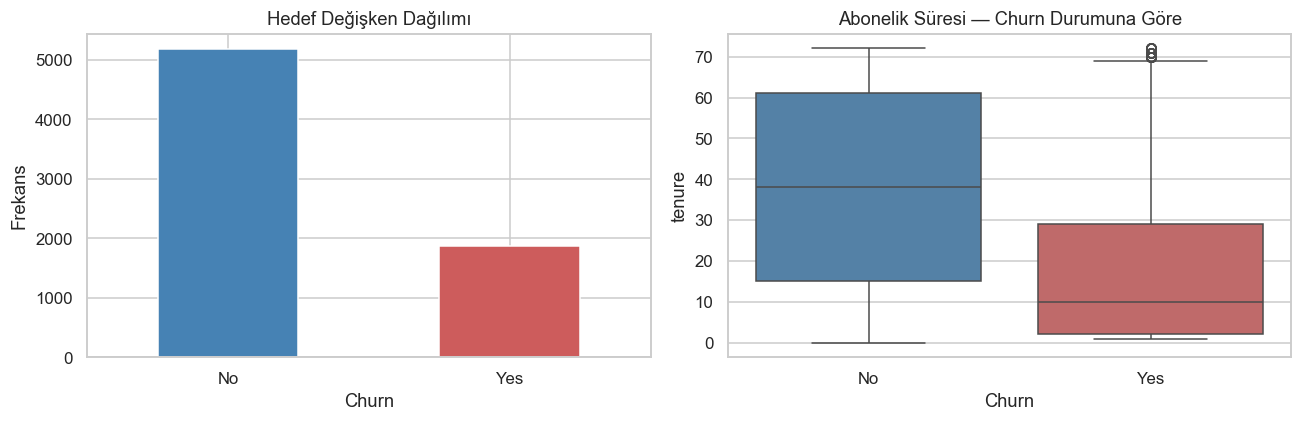


⚠️  SINIF DENGESİZLİĞİ: Azınlık sınıfı %26.5
   class_weight='balanced' kullanılacak.
   DİKKAT: Hiç kimseye 'ayrılacak' demeyen boş bir model %73.5
   doğruluk alır. Bu yüzden asıl karşılaştırma ROC-AUC ve recall üzerinden yapılacak.


In [7]:
print("Eksik değer toplamı:", df.isnull().sum().sum())
dagilim = df[HEDEF].value_counts(normalize=True)
print("\nSınıf dağılımı:")
print(dagilim.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[HEDEF].value_counts().plot(kind="bar", color=["steelblue", "indianred"], ax=axes[0])
axes[0].set_title("Hedef Değişken Dağılımı"); axes[0].set_xlabel(HEDEF); axes[0].set_ylabel("Frekans")
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(x=HEDEF, y='tenure', data=df, ax=axes[1], palette=["steelblue", "indianred"])
axes[1].set_title("Abonelik Süresi — Churn Durumuna Göre")

plt.tight_layout(); plt.show()

if dagilim.min() < 0.30:
    print(f"\n⚠️  SINIF DENGESİZLİĞİ: Azınlık sınıfı %{dagilim.min()*100:.1f}")
    print("   class_weight='balanced' kullanılacak.")
    print(f"   DİKKAT: Hiç kimseye 'ayrılacak' demeyen boş bir model %{dagilim.max()*100:.1f}")
    print("   doğruluk alır. Bu yüzden asıl karşılaştırma ROC-AUC ve recall üzerinden yapılacak.")

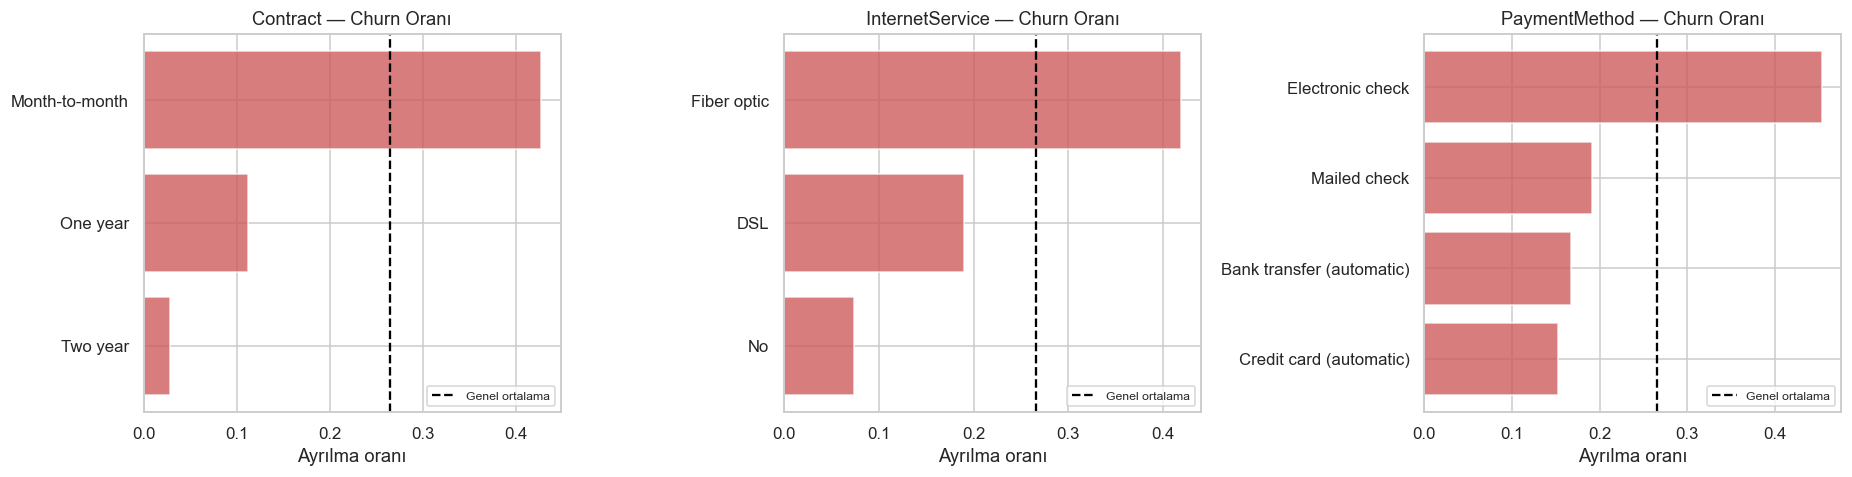

Aylık sözleşmeli müşterilerde ayrılma oranı belirgin şekilde yüksek.
Bu, modelin bulmasını beklediğimiz en güçlü sinyal.


In [8]:
# Sözleşme tipi ve ödeme yöntemine göre churn oranları
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, kolon in zip(axes, ['Contract', 'InternetService', 'PaymentMethod']):
    oran = df.groupby(kolon)[HEDEF].apply(lambda s: (s == 'Yes').mean()).sort_values()
    ax.barh(oran.index, oran.values, color='indianred', alpha=0.8)
    ax.axvline(dagilim.get('Yes', 0.265), color='black', linestyle='--',
               linewidth=1.5, label='Genel ortalama')
    ax.set_title(f'{kolon} — Churn Oranı')
    ax.set_xlabel('Ayrılma oranı')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print("Aylık sözleşmeli müşterilerde ayrılma oranı belirgin şekilde yüksek.")
print("Bu, modelin bulmasını beklediğimiz en güçlü sinyal.")

## 4. Veri Ön İşleme

`customerID` çıkarılıyor, `TotalCharges` sayısala çevriliyor (`errors='coerce'` + medyan), kategorik sütunlara `drop_first=True` ile one-hot uygulanıyor.

In [9]:
df_clean = df.copy()

# ADIM 1 — Kimlik sütununu çıkar
df_clean = df_clean.drop(columns=['customerID'])
print("✅ customerID çıkarıldı")

# ADIM 2 — TotalCharges'ı sayısala çevir
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
nan_sayisi = df_clean['TotalCharges'].isna().sum()
medyan = df_clean['TotalCharges'].median()
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(medyan)
print(f"✅ TotalCharges sayısala çevrildi | {nan_sayisi} NaN medyanla ({medyan:.2f}) dolduruldu")

# ADIM 3 — Kalan eksik değerler
for col in df_clean.columns:
    if df_clean[col].isnull().any():
        if pd.api.types.is_numeric_dtype(df_clean[col]):
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# ADIM 4 — Hedef ve özellik ayrımı, one-hot encoding
y = df_clean[HEDEF]
X = pd.get_dummies(df_clean.drop(columns=[HEDEF]), drop_first=True).astype(float)

if not pd.api.types.is_numeric_dtype(y):
    y = pd.Series(LabelEncoder().fit_transform(y), name=HEDEF)
    print("✅ Hedef değişken sayısal olarak kodlandı (No=0, Yes=1)")

print(f"\n📌 Özellik matrisi: {X.shape} | Hedef: {y.shape}")
print(f"📌 Özellikler: {list(X.columns)}")

✅ customerID çıkarıldı
✅ TotalCharges sayısala çevrildi | 11 NaN medyanla (1397.47) dolduruldu
✅ Hedef değişken sayısal olarak kodlandı (No=0, Yes=1)

📌 Özellik matrisi: (7043, 30) | Hedef: (7043,)
📌 Özellikler: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### 4.1 Ön İşlemenin Etkisi

Aşağıda, düzeltme yapılmadan aynı `get_dummies` çağrısının ne ürettiği ve bunun model sıralamasına etkisi gösteriliyor.

In [10]:
# Düzeltme YAPILMADAN one-hot encoding
X_hatali = pd.get_dummies(df.drop(columns=[HEDEF]), drop_first=True)

print("=" * 60)
print("ÖN İŞLEME KARŞILAŞTIRMASI")
print("=" * 60)
print(f"  Düzeltme yapılmadan : {X_hatali.shape[1]:>6} özellik")
print(f"  Düzeltme yapıldıktan: {X.shape[1]:>6} özellik")
print(f"  Fark                : {X_hatali.shape[1] - X.shape[1]:>6} gereksiz sütun")
print()
print("Fazladan gelen sütunlar nereden geliyor?")
print(f"  customerID   : {df['customerID'].nunique() - 1:>5} kukla sütun (her müşteri için ayrı)")
print(f"  TotalCharges : {df['TotalCharges'].nunique() - 1:>5} kukla sütun (metin sanıldığı için)")
print()
print("SONUÇ: 21 sütunluk veri setinden 13 binden fazla özellik üretiliyor.")
print("       Bu sütunların büyük bölümü müşteri kimliği ve metin olarak kalan TotalCharges değerlerinden türetilmiş, genelleme açısından sınırlı bilgi taşıması beklenen özelliklerdir.")

ÖN İŞLEME KARŞILAŞTIRMASI
  Düzeltme yapılmadan :  13601 özellik
  Düzeltme yapıldıktan:     30 özellik
  Fark                :  13571 gereksiz sütun

Fazladan gelen sütunlar nereden geliyor?
  customerID   :  7042 kukla sütun (her müşteri için ayrı)
  TotalCharges :  6530 kukla sütun (metin sanıldığı için)

SONUÇ: 21 sütunluk veri setinden 13 binden fazla özellik üretiliyor.
       Bu sütunların büyük bölümü müşteri kimliği ve metin olarak kalan TotalCharges değerlerinden türetilmiş, genelleme açısından sınırlı bilgi taşıması beklenen özelliklerdir.


In [11]:
# Hatalı özellik matrisinin modellere etkisi
X_h = X_hatali.astype(float)
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
    X_h, y, test_size=0.25, random_state=SEED, stratify=y
)

print("HATALI ÖN İŞLEME İLE MODEL SONUÇLARI")
print("─" * 60)
hatali_sonuc = {}
for model, ad in [
    (DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, class_weight="balanced", random_state=SEED), "Decision Tree"),
    (RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight="balanced", n_jobs=-1, random_state=SEED), "Random Forest")
]:
    model.fit(Xh_tr, yh_tr)
    p = model.predict(Xh_te)
    pr = model.predict_proba(Xh_te)[:, 1]
    hatali_sonuc[ad] = {'acc': accuracy_score(yh_te, p), 'auc': roc_auc_score(yh_te, pr)}
    print(f"  {ad:<16} Doğruluk={hatali_sonuc[ad]['acc']:.4f}  ROC-AUC={hatali_sonuc[ad]['auc']:.4f}")

print()
print("🔑 DİKKAT: Random Forest, Decision Tree'nin ALTINDA kalıyor.")
print("   Bu sonuç, yüksek boyutlu ve büyük ölçüde kimlik/değer bazlı kukla değişkenlerden oluşan özellik uzayının Random Forest performansını olumsuz etkileyebileceğini düşündürmektedir:")
print("   Random Forest her düğümde özelliklerin RASTGELE bir alt kümesine bakar.")
print("   13.601 özelliğin 13.572'si gürültü olunca, seçilen alt küme neredeyse")
print("   her zaman gürültüden oluşuyor. Decision Tree ise tüm özellikleri")
print("   gördüğü için işe yarayanları bulabiliyor.")
print()
print("   Bölüm 6'da düzeltilmiş veriyle bu sıralamanın tersine döndüğünü göreceğiz.")

HATALI ÖN İŞLEME İLE MODEL SONUÇLARI
────────────────────────────────────────────────────────────
  Decision Tree    Doğruluk=0.7501  ROC-AUC=0.8272
  Random Forest    Doğruluk=0.5985  ROC-AUC=0.8112

🔑 DİKKAT: Random Forest, Decision Tree'nin ALTINDA kalıyor.
   Bu sonuç, yüksek boyutlu ve büyük ölçüde kimlik/değer bazlı kukla değişkenlerden oluşan özellik uzayının Random Forest performansını olumsuz etkileyebileceğini düşündürmektedir:
   Random Forest her düğümde özelliklerin RASTGELE bir alt kümesine bakar.
   13.601 özelliğin 13.572'si gürültü olunca, seçilen alt küme neredeyse
   her zaman gürültüden oluşuyor. Decision Tree ise tüm özellikleri
   gördüğü için işe yarayanları bulabiliyor.

   Bölüm 6'da düzeltilmiş veriyle bu sıralamanın tersine döndüğünü göreceğiz.


## 5. Eğitim / Test Ayrımı ve Referans Seviyesi

In [12]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)
print(f"Eğitim seti: {len(X_tr)} | Test seti: {len(X_te)}")
print(f"Eğitim churn oranı: {y_tr.mean():.4f} | Test churn oranı: {y_te.mean():.4f}")
print("(stratify sayesinde oranlar korundu)")

Eğitim seti: 5282 | Test seti: 1761
Eğitim churn oranı: 0.2654 | Test churn oranı: 0.2652
(stratify sayesinde oranlar korundu)


In [13]:
# Referans (baseline) seviyeleri — modelleri değerlendirmeden önce
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
ref_acc = accuracy_score(y_te, dummy.predict(X_te))

print("=" * 55)
print("REFERANS (BASELINE) SEVİYELERİ")
print("=" * 55)
print(f"  'Hiç kimse ayrılmaz' diyen model — Doğruluk: {ref_acc:.4f}")
print(f"  'Hiç kimse ayrılmaz' diyen model — ROC-AUC : 0.5000")
print(f"  'Hiç kimse ayrılmaz' diyen model — Recall(1): 0.0000")
print()
print(">>> Doğruluk metriğinin tuzağı: %73.5 doğruluk alan bu model, ayrılacak")
print("    hiçbir müşteriyi bulamıyor. Ticari olarak tamamen değersiz.")
print(">>> Modellerimizi ROC-AUC ve azınlık sınıfı recall'ı üzerinden değerlendireceğiz.")

REFERANS (BASELINE) SEVİYELERİ
  'Hiç kimse ayrılmaz' diyen model — Doğruluk: 0.7348
  'Hiç kimse ayrılmaz' diyen model — ROC-AUC : 0.5000
  'Hiç kimse ayrılmaz' diyen model — Recall(1): 0.0000

>>> Doğruluk metriğinin tuzağı: %73.5 doğruluk alan bu model, ayrılacak
    hiçbir müşteriyi bulamıyor. Ticari olarak tamamen değersiz.
>>> Modellerimizi ROC-AUC ve azınlık sınıfı recall'ı üzerinden değerlendireceğiz.


## 6. Model Eğitimi ve Karşılaştırma

Her iki model aynı `değerlendir()` fonksiyonundan geçiriliyor. `class_weight='balanced'` ile azınlık sınıfına daha yüksek ağırlık veriliyor.

In [14]:
def degerlendir(model, ad):
    # Modeli eğitir; test seti ve çapraz doğrulama metriklerini döndürür.
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    cv_skor = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="roc_auc")

    m = {
        "Model": ad,
        "Doğruluk (Accuracy)": accuracy_score(y_te, y_pred),
        "Kesinlik (Precision)": precision_score(y_te, y_pred, zero_division=0),
        "Duyarlılık (Recall)": recall_score(y_te, y_pred),
        "F1 Skoru": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "CV AUC Ortalama": cv_skor.mean(),
        "CV AUC Std": cv_skor.std(),
    }

    print(f"--- {ad} ---")
    print(classification_report(y_te, y_pred, zero_division=0,
                                target_names=["Kalıyor (0)", "Ayrılıyor (1)"]))
    return model, y_pred, m


dt_model = DecisionTreeClassifier(max_depth=6, min_samples_leaf=5,
                                  class_weight="balanced", random_state=SEED)
rf_model = RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                  class_weight="balanced", n_jobs=-1, random_state=SEED)

dt, dt_pred, dt_m = degerlendir(dt_model, "Decision Tree")
rf, rf_pred, rf_m = degerlendir(rf_model, "Random Forest")

--- Decision Tree ---
               precision    recall  f1-score   support

  Kalıyor (0)       0.91      0.69      0.78      1294
Ayrılıyor (1)       0.49      0.81      0.61       467

     accuracy                           0.72      1761
    macro avg       0.70      0.75      0.70      1761
 weighted avg       0.80      0.72      0.74      1761

--- Random Forest ---
               precision    recall  f1-score   support

  Kalıyor (0)       0.86      0.84      0.85      1294
Ayrılıyor (1)       0.59      0.63      0.61       467

     accuracy                           0.78      1761
    macro avg       0.72      0.74      0.73      1761
 weighted avg       0.79      0.78      0.79      1761



In [15]:
tablo = pd.DataFrame([dt_m, rf_m]).set_index("Model").round(4)
tablo.to_csv("model_karsilastirma.csv")
print("MODEL KARŞILAŞTIRMA TABLOSU")
print(tablo.T.to_string())

MODEL KARŞILAŞTIRMA TABLOSU
Model                 Decision Tree  Random Forest
Doğruluk (Accuracy)          0.7217         0.7842
Kesinlik (Precision)         0.4853         0.5865
Duyarlılık (Recall)          0.8116         0.6317
F1 Skoru                     0.6074         0.6082
ROC-AUC                      0.8269         0.8402
CV AUC Ortalama              0.8194         0.8371
CV AUC Std                   0.0108         0.0114


In [16]:
# Hatalı ön işleme ile düzeltilmiş sonuçların yan yana karşılaştırması
print("=" * 68)
print("ÖN İŞLEMENİN ETKİSİ — AYNI MODELLER, FARKLI VERİ HAZIRLIĞI")
print("=" * 68)
print(f"{'':<18} {'HATALI (13.601 özellik)':>24} {'DÜZELTİLMİŞ (30 özellik)':>25}")
print("─" * 68)
print(f"{'Decision Tree':<18} {hatali_sonuc['Decision Tree']['auc']:>24.4f} {dt_m['ROC-AUC']:>25.4f}")
print(f"{'Random Forest':<18} {hatali_sonuc['Random Forest']['auc']:>24.4f} {rf_m['ROC-AUC']:>25.4f}")
print("─" * 68)
kazanan_hatali = "Decision Tree" if hatali_sonuc['Decision Tree']['auc'] > hatali_sonuc['Random Forest']['auc'] else "Random Forest"
kazanan_dogru = "Decision Tree" if dt_m['ROC-AUC'] > rf_m['ROC-AUC'] else "Random Forest"
print(f"{'KAZANAN':<18} {kazanan_hatali:>24} {kazanan_dogru:>25}")
print()
print("Ön işleme düzeltilince sıralama tersine döndü. Aynı algoritmalar,")
print("aynı hiperparametreler — bu karşılaştırmada değişen temel unsur verinin hazırlanma biçimidir.")

ÖN İŞLEMENİN ETKİSİ — AYNI MODELLER, FARKLI VERİ HAZIRLIĞI
                    HATALI (13.601 özellik)  DÜZELTİLMİŞ (30 özellik)
────────────────────────────────────────────────────────────────────
Decision Tree                        0.8272                    0.8269
Random Forest                        0.8112                    0.8402
────────────────────────────────────────────────────────────────────
KAZANAN                       Decision Tree             Random Forest

Ön işleme düzeltilince sıralama tersine döndü. Aynı algoritmalar,
aynı hiperparametreler — bu karşılaştırmada değişen temel unsur verinin hazırlanma biçimidir.


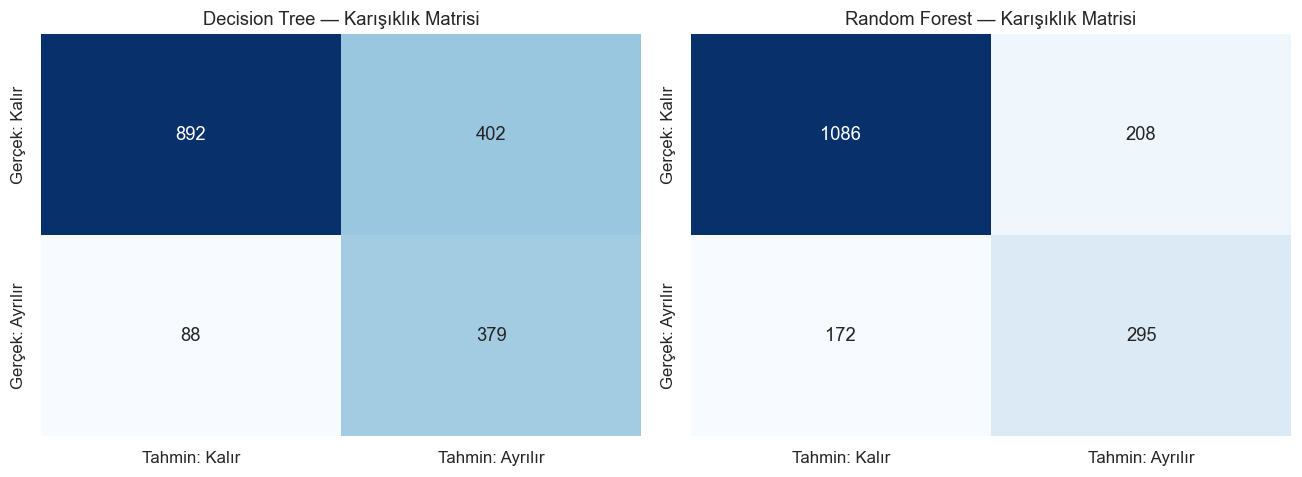

Sol alt hücre (FN) = ayrılacağını fark edemediğimiz müşteriler → en pahalı hata
Sağ üst hücre (FP) = boşuna kampanya yaptığımız müşteriler → görece ucuz hata
  Decision Tree   :  88 kaçırılan ayrılık | 402 gereksiz kampanya
  Random Forest   : 172 kaçırılan ayrılık | 208 gereksiz kampanya


In [17]:
# Karışıklık matrisleri
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (ad, pred) in zip(axes, [("Decision Tree", dt_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_te, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Tahmin: Kalır", "Tahmin: Ayrılır"],
                yticklabels=["Gerçek: Kalır", "Gerçek: Ayrılır"])
    ax.set_title(f"{ad} — Karışıklık Matrisi")
plt.tight_layout(); plt.show()

print("Sol alt hücre (FN) = ayrılacağını fark edemediğimiz müşteriler → en pahalı hata")
print("Sağ üst hücre (FP) = boşuna kampanya yaptığımız müşteriler → görece ucuz hata")
for ad, pred in [("Decision Tree", dt_pred), ("Random Forest", rf_pred)]:
    cm = confusion_matrix(y_te, pred)
    print(f"  {ad:<16}: {cm[1,0]:>3} kaçırılan ayrılık | {cm[0,1]:>3} gereksiz kampanya")

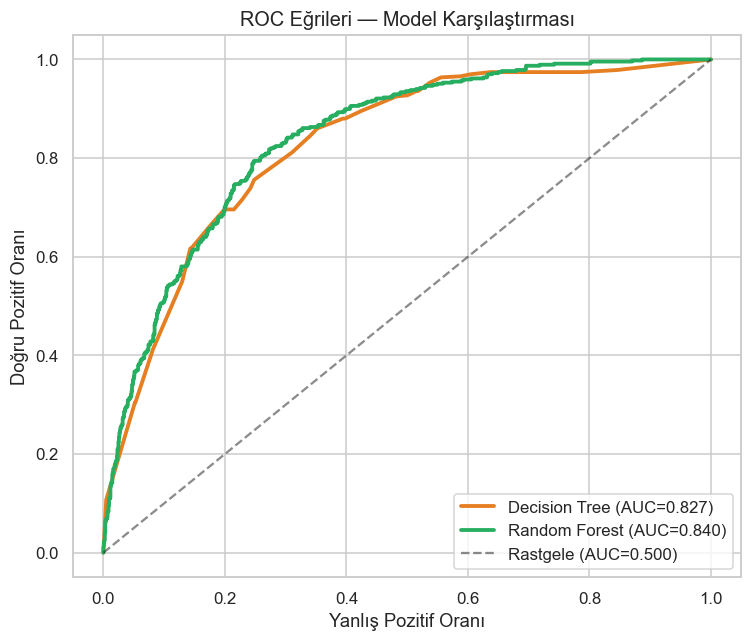

In [18]:
# ROC eğrileri
fig, ax = plt.subplots(figsize=(7, 6))
for model, ad, renk in [(dt, "Decision Tree", "#e67e22"), (rf, "Random Forest", "#27ae60")]:
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax.plot(fpr, tpr, linewidth=2.5, color=renk,
            label=f"{ad} (AUC={roc_auc_score(y_te, proba):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Rastgele (AUC=0.500)")
ax.set_title("ROC Eğrileri — Model Karşılaştırması", fontsize=13)
ax.set_xlabel("Yanlış Pozitif Oranı"); ax.set_ylabel("Doğru Pozitif Oranı")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Ağaç Derinliğine Göre Aşırı Uyum Analizi

Her iki model 1'den sınırsıza kadar farklı derinliklerde eğitilip eğitim ve test AUC değerleri karşılaştırılıyor.

In [19]:
derinlikler = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
egri = []

print("Derinlik taraması çalışıyor...")
for d in derinlikler:
    dt_d = DecisionTreeClassifier(max_depth=d, class_weight="balanced",
                                  random_state=SEED).fit(X_tr, y_tr)
    rf_d = RandomForestClassifier(n_estimators=200, max_depth=d, class_weight="balanced",
                                  n_jobs=-1, random_state=SEED).fit(X_tr, y_tr)
    egri.append({
        "Derinlik": d if d is not None else "Sınırsız",
        "DT Eğitim": roc_auc_score(y_tr, dt_d.predict_proba(X_tr)[:, 1]),
        "DT Test":   roc_auc_score(y_te, dt_d.predict_proba(X_te)[:, 1]),
        "RF Eğitim": roc_auc_score(y_tr, rf_d.predict_proba(X_tr)[:, 1]),
        "RF Test":   roc_auc_score(y_te, rf_d.predict_proba(X_te)[:, 1]),
    })

egri_df = pd.DataFrame(egri)
egri_df["DT Makas"] = (egri_df["DT Eğitim"] - egri_df["DT Test"]).round(3)
egri_df["RF Makas"] = (egri_df["RF Eğitim"] - egri_df["RF Test"]).round(3)
print()
print(egri_df.round(3).to_string(index=False))

Derinlik taraması çalışıyor...

Derinlik  DT Eğitim  DT Test  RF Eğitim  RF Test  DT Makas  RF Makas
       1      0.645    0.650      0.823    0.819    -0.005     0.004
       2      0.740    0.742      0.834    0.831    -0.002     0.003
       3      0.798    0.794      0.842    0.837     0.005     0.005
       4      0.829    0.822      0.850    0.842     0.007     0.008
       5      0.845    0.832      0.858    0.844     0.014     0.014
       6      0.861    0.827      0.868    0.845     0.034     0.023
       8      0.895    0.804      0.900    0.845     0.092     0.055
      10      0.931    0.768      0.942    0.843     0.163     0.099
      15      0.987    0.696      0.997    0.832     0.291     0.165
      20      0.999    0.663      1.000    0.830     0.336     0.170
Sınırsız      1.000    0.654      1.000    0.830     0.346     0.170


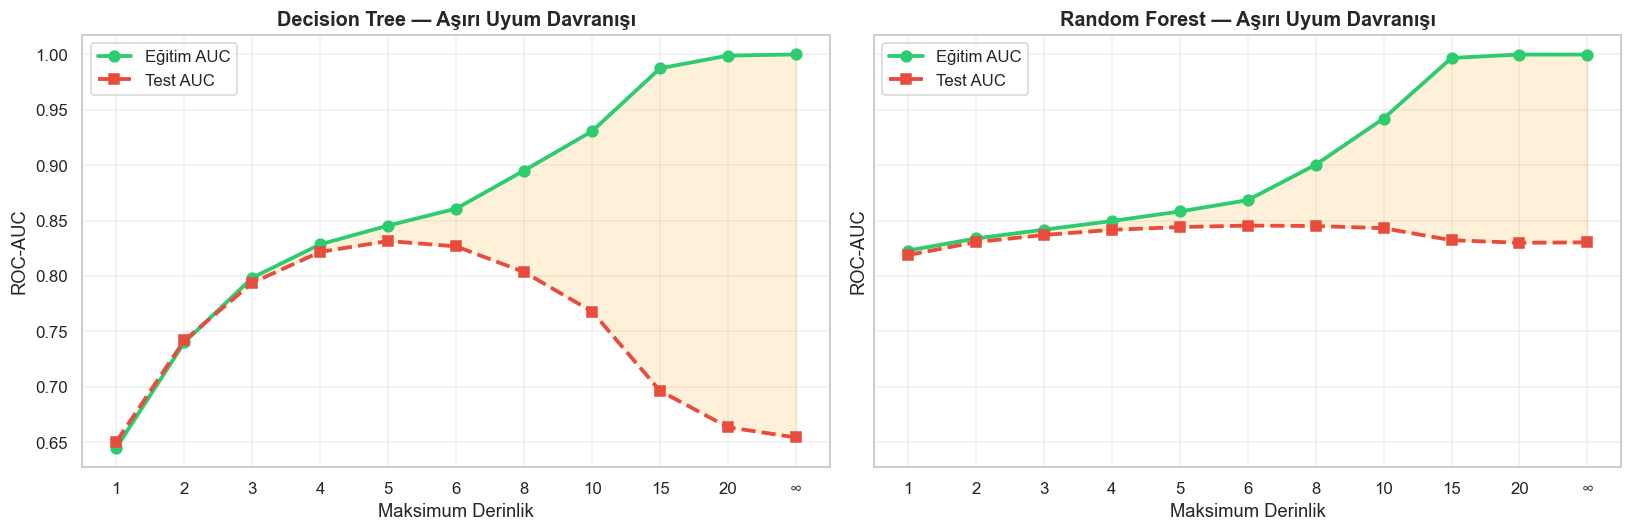

Decision Tree en iyi test AUC: 0.832 (derinlik=5)
Decision Tree sınırsız derinlikte: 0.654 (düşüş: 0.177)
Random Forest sınırsız derinlikte: 0.830 (eğitim AUC 1.000 olmasına rağmen)

🔑 İşte fark bu: her iki model de eğitim verisini tamamen ezberliyor
   (eğitim AUC ≈ 1.000), ama sadece Decision Tree'nin test performansı çöküyor.
   Random Forest ezberlerken bile genelleme yeteneğini koruyor.


In [20]:
# Aşırı uyum eğrilerinin görselleştirilmesi
x_ekseni = list(range(len(derinlikler)))
etiketler = [str(d) if d is not None else "∞" for d in derinlikler]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, (ad, tr_kol, te_kol) in zip(axes,
        [("Decision Tree", "DT Eğitim", "DT Test"), ("Random Forest", "RF Eğitim", "RF Test")]):
    ax.plot(x_ekseni, egri_df[tr_kol], "o-", color="#2ecc71", linewidth=2.5,
            markersize=7, label="Eğitim AUC")
    ax.plot(x_ekseni, egri_df[te_kol], "s--", color="#e74c3c", linewidth=2.5,
            markersize=7, label="Test AUC")
    ax.fill_between(x_ekseni, egri_df[tr_kol], egri_df[te_kol], alpha=0.15, color="orange")
    ax.set_xticks(x_ekseni); ax.set_xticklabels(etiketler)
    ax.set_xlabel("Maksimum Derinlik"); ax.set_ylabel("ROC-AUC")
    ax.set_title(f"{ad} — Aşırı Uyum Davranışı", fontsize=13, fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

dt_tepe = egri_df.loc[egri_df["DT Test"].idxmax()]
dt_son = egri_df.iloc[-1]
rf_son = egri_df.iloc[-1]
print(f"Decision Tree en iyi test AUC: {dt_tepe['DT Test']:.3f} (derinlik={dt_tepe['Derinlik']})")
print(f"Decision Tree sınırsız derinlikte: {dt_son['DT Test']:.3f} "
      f"(düşüş: {dt_tepe['DT Test'] - dt_son['DT Test']:.3f})")
print(f"Random Forest sınırsız derinlikte: {rf_son['RF Test']:.3f} "
      f"(eğitim AUC {rf_son['RF Eğitim']:.3f} olmasına rağmen)")
print()
print("🔑 İşte fark bu: her iki model de eğitim verisini tamamen ezberliyor")
print("   (eğitim AUC ≈ 1.000), ama sadece Decision Tree'nin test performansı çöküyor.")
print("   Random Forest ezberlerken bile genelleme yeteneğini koruyor.")

## 8. Hiperparametre Optimizasyonu

Karşılaştırmanın adil olması için her iki model de kendi en iyi ayarında değerlendiriliyor. Optimizasyon metriği ROC-AUC (sınıf dengesizliği nedeniyle doğruluk uygun değil).

In [21]:
print("🔍 Decision Tree grid search başlıyor…")
dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=SEED),
    {
        "max_depth": [3, 4, 5, 6, 8, 10, None],
        "min_samples_leaf": [1, 5, 10, 20],
        "criterion": ["gini", "entropy"],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1
)
dt_grid.fit(X_tr, y_tr)

print(f"  En iyi parametreler: {dt_grid.best_params_}")
print(f"  CV AUC: {dt_grid.best_score_:.4f}")

🔍 Decision Tree grid search başlıyor…
  En iyi parametreler: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 20}
  CV AUC: 0.8259


In [22]:
print("🔍 Random Forest grid search başlıyor…")
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=SEED),
    {
        "n_estimators": [200, 400],
        "max_depth": [8, 12, None],
        "min_samples_leaf": [1, 2, 5],
        "max_features": ["sqrt", 0.5],
    },
    cv=cv, scoring="roc_auc", n_jobs=-1
)
rf_grid.fit(X_tr, y_tr)

print(f"  En iyi parametreler: {rf_grid.best_params_}")
print(f"  CV AUC: {rf_grid.best_score_:.4f}")

🔍 Random Forest grid search başlıyor…
  En iyi parametreler: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}
  CV AUC: 0.8457


In [23]:
dt_best, rf_best = dt_grid.best_estimator_, rf_grid.best_estimator_

optimize = []
for model, ad in [(dt_best, "Decision Tree (optimize)"), (rf_best, "Random Forest (optimize)")]:
    p = model.predict(X_te)
    pr = model.predict_proba(X_te)[:, 1]
    optimize.append({
        "Model": ad,
        "Doğruluk": accuracy_score(y_te, p),
        "Kesinlik": precision_score(y_te, p, zero_division=0),
        "Duyarlılık": recall_score(y_te, p),
        "F1": f1_score(y_te, p),
        "ROC-AUC": roc_auc_score(y_te, pr),
    })

print("=" * 70)
print("TEMEL MODELLER  vs  OPTİMİZE EDİLMİŞ MODELLER (ROC-AUC)")
print("=" * 70)
print(f"  Decision Tree : {dt_m['ROC-AUC']:.4f}  →  {optimize[0]['ROC-AUC']:.4f}   "
      f"({'▲' if optimize[0]['ROC-AUC'] >= dt_m['ROC-AUC'] else '▼'} "
      f"{abs(optimize[0]['ROC-AUC'] - dt_m['ROC-AUC']):.4f})")
print(f"  Random Forest : {rf_m['ROC-AUC']:.4f}  →  {optimize[1]['ROC-AUC']:.4f}   "
      f"({'▲' if optimize[1]['ROC-AUC'] >= rf_m['ROC-AUC'] else '▼'} "
      f"{abs(optimize[1]['ROC-AUC'] - rf_m['ROC-AUC']):.4f})")
print("=" * 70)
print()
print("OPTİMİZE MODELLERİN TÜM METRİKLERİ:")
print(pd.DataFrame(optimize).set_index("Model").round(4).T.to_string())
print()
print(f"AUC farkı (RF - DT): {optimize[1]['ROC-AUC'] - optimize[0]['ROC-AUC']:+.4f}")
print("Her iki model de kendi en iyi ayarındayken bile Random Forest önde.")

TEMEL MODELLER  vs  OPTİMİZE EDİLMİŞ MODELLER (ROC-AUC)
  Decision Tree : 0.8269  →  0.8325   (▲ 0.0056)
  Random Forest : 0.8402  →  0.8465   (▲ 0.0063)

OPTİMİZE MODELLERİN TÜM METRİKLERİ:
Model       Decision Tree (optimize)  Random Forest (optimize)
Doğruluk                      0.7541                    0.7672
Kesinlik                      0.5259                    0.5416
Duyarlılık                    0.7388                    0.7944
F1                            0.6144                    0.6441
ROC-AUC                       0.8325                    0.8465

AUC farkı (RF - DT): +0.0140
Her iki model de kendi en iyi ayarındayken bile Random Forest önde.


## 9. Özellik Önem Sıralaması — İki Modelin Karşılaştırması

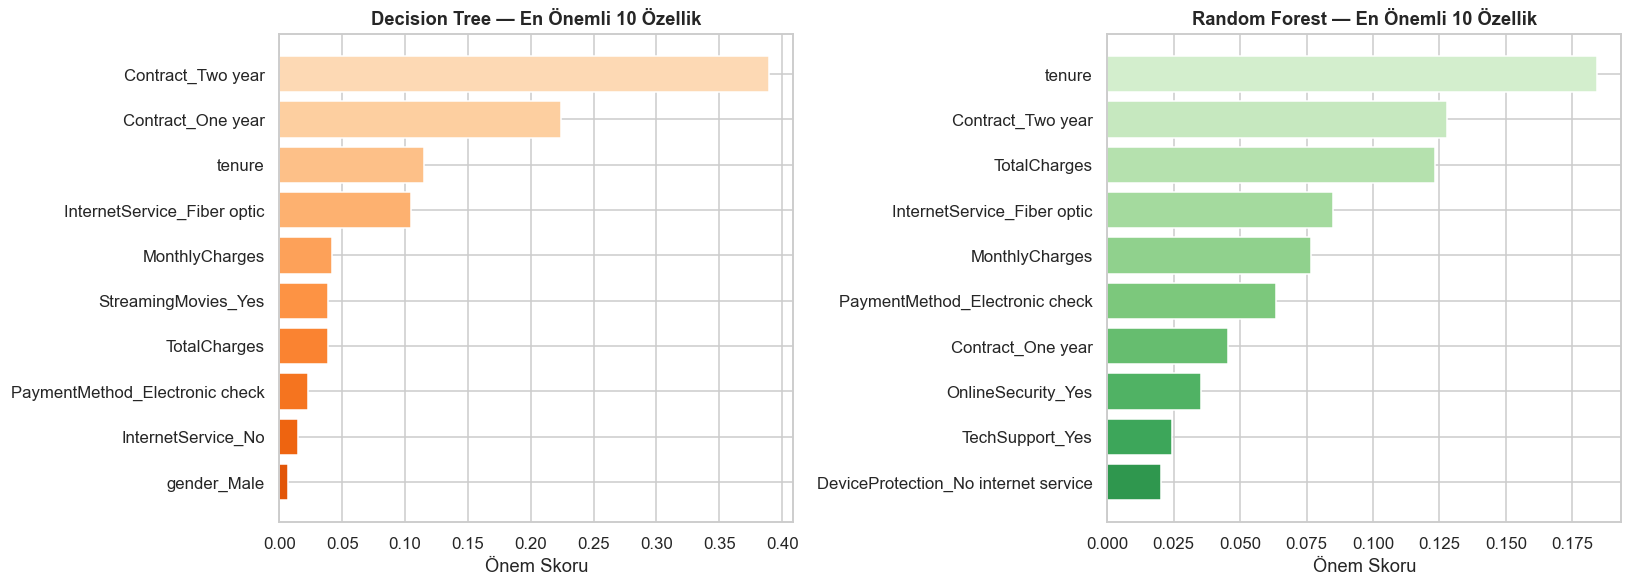

Decision Tree'nin hiç kullanmadığı özellik sayısı: 19 / 30
Random Forest'ın hiç kullanmadığı özellik sayısı  : 0 / 30

Decision Tree tek bir bölünme yolu izlediği için özelliklerin çoğunu hiç kullanmaz.
Random Forest, rastgele özellik seçimi sayesinde tüm özelliklere şans verir;
bu yüzden önem skorları daha dengeli dağılır ve daha güvenilirdir.


In [24]:
dt_onem = pd.Series(dt_best.feature_importances_, index=X.columns)
rf_onem = pd.Series(rf_best.feature_importances_, index=X.columns)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, (onem, ad, renk) in zip(axes,
        [(dt_onem, "Decision Tree", "Oranges_r"), (rf_onem, "Random Forest", "Greens_r")]):
    top = onem.nlargest(10).sort_values()
    ax.barh(top.index, top.values, color=plt.get_cmap(renk)(np.linspace(0.3, 0.8, len(top))))
    ax.set_title(f"{ad} — En Önemli 10 Özellik", fontsize=12, fontweight="bold")
    ax.set_xlabel("Önem Skoru")

plt.tight_layout(); plt.show()

# Sıfır önem alan özellik sayısı
print(f"Decision Tree'nin hiç kullanmadığı özellik sayısı: {(dt_onem == 0).sum()} / {len(dt_onem)}")
print(f"Random Forest'ın hiç kullanmadığı özellik sayısı  : {(rf_onem == 0).sum()} / {len(rf_onem)}")
print()
print("Decision Tree tek bir bölünme yolu izlediği için özelliklerin çoğunu hiç kullanmaz.")
print("Random Forest, rastgele özellik seçimi sayesinde tüm özelliklere şans verir;")
print("bu yüzden önem skorları daha dengeli dağılır ve daha güvenilirdir.")

In [25]:
# İki modelin sıralamalarının karşılaştırılması
karsilastirma_onem = pd.DataFrame({
    "DT Önem": dt_onem,
    "RF Önem": rf_onem,
}).sort_values("RF Önem", ascending=False).head(12)

karsilastirma_onem["DT Sıra"] = dt_onem.rank(ascending=False).astype(int)
karsilastirma_onem["RF Sıra"] = rf_onem.rank(ascending=False).astype(int)

print("EN ÖNEMLİ 12 ÖZELLİK (Random Forest sırasına göre):")
print(karsilastirma_onem.round(4).to_string())

korelasyon = dt_onem.corr(rf_onem, method="spearman")
print(f"\nİki modelin önem sıralamaları arasındaki Spearman korelasyonu: {korelasyon:.3f}")

EN ÖNEMLİ 12 ÖZELLİK (Random Forest sırasına göre):
                                      DT Önem  RF Önem  DT Sıra  RF Sıra
tenure                                 0.1153   0.1843        3        1
Contract_Two year                      0.3895   0.1277        1        2
TotalCharges                           0.0385   0.1232        7        3
InternetService_Fiber optic            0.1047   0.0848        4        4
MonthlyCharges                         0.0420   0.0767        5        5
PaymentMethod_Electronic check         0.0230   0.0634        8        6
Contract_One year                      0.2239   0.0456        2        7
OnlineSecurity_Yes                     0.0000   0.0351       21        8
TechSupport_Yes                        0.0000   0.0244       21        9
DeviceProtection_No internet service   0.0000   0.0201       21       10
OnlineSecurity_No internet service     0.0000   0.0195       21       11
TechSupport_No internet service        0.0000   0.0184       21       12

## 10. Karar Ağacının Görselleştirilmesi

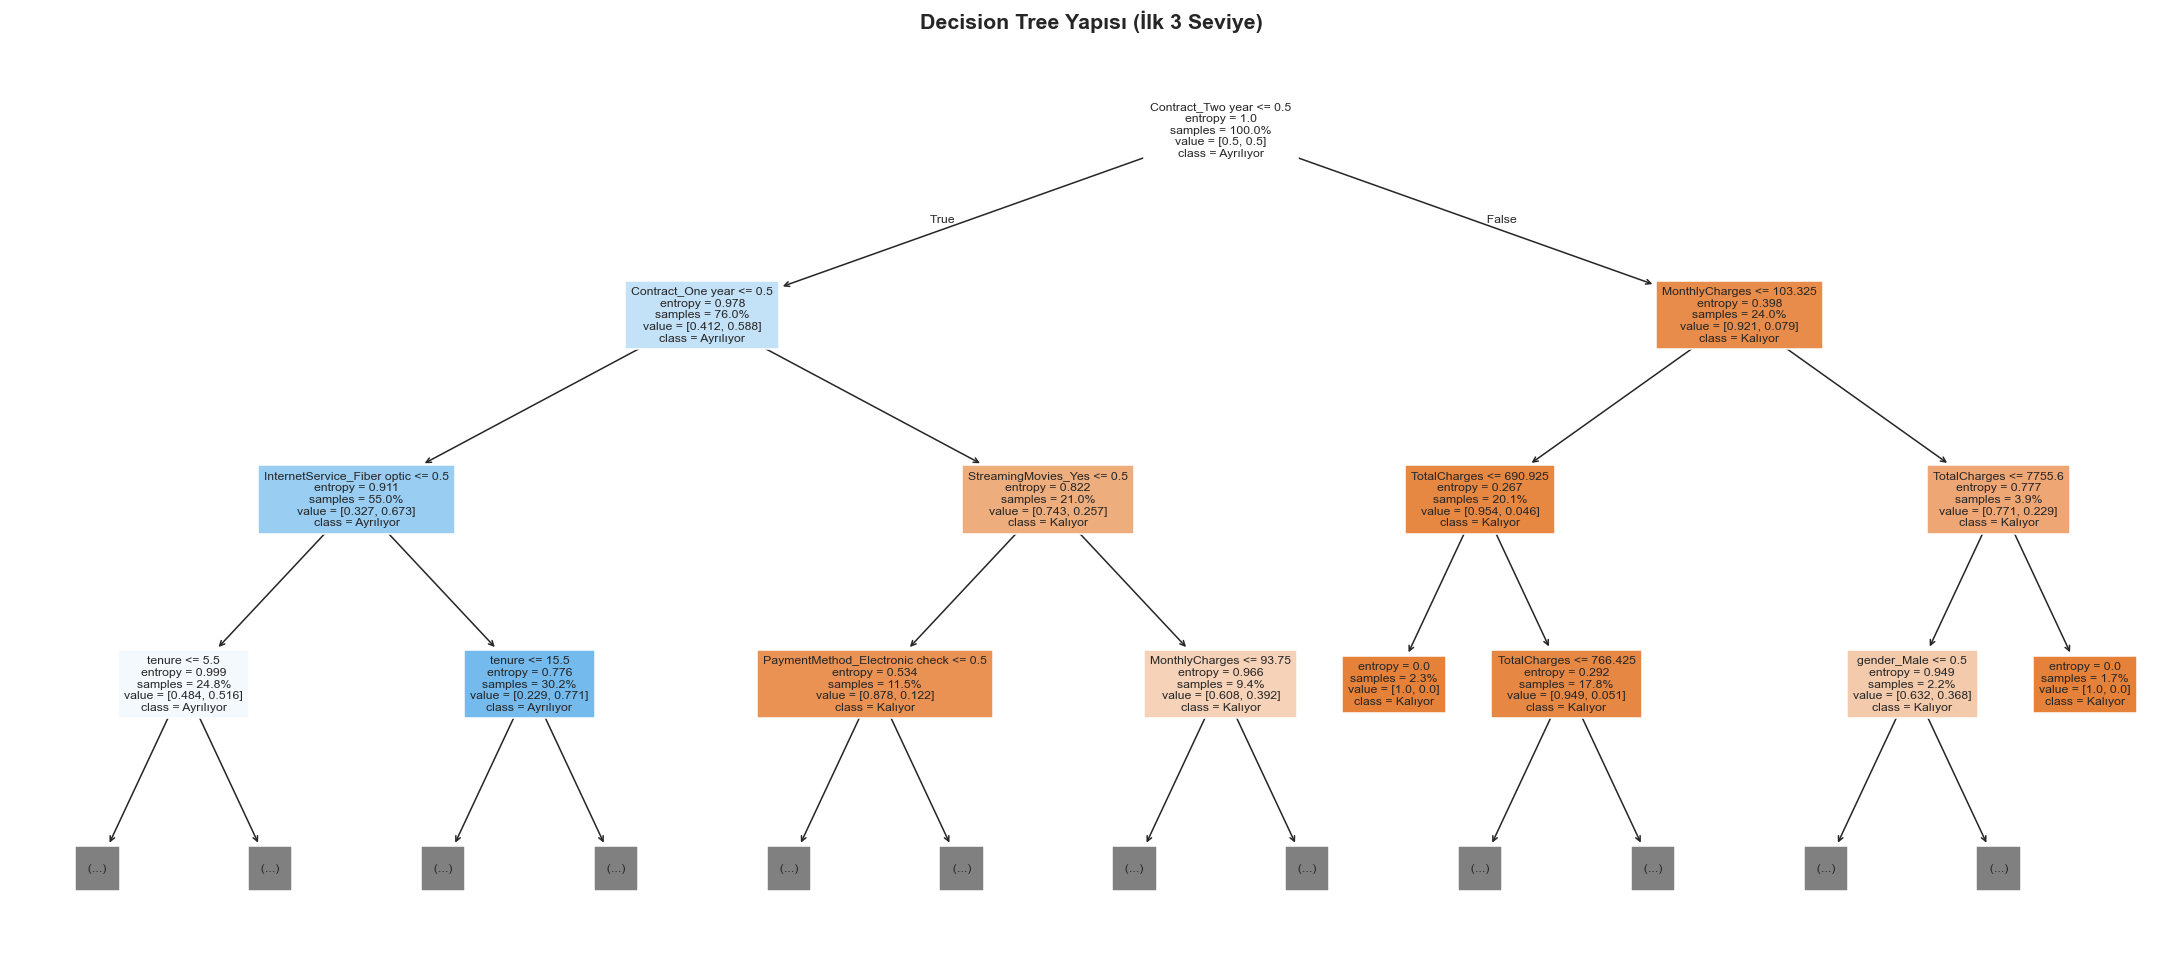

Decision Tree'nin en büyük avantajı burada: karar mantığı doğrudan okunabiliyor.
Random Forest'ta böyle bir görsel mümkün değil — yüzlerce ağacın oyu var.
Yorumlanabilirlik ile doğruluk arasındaki klasik ödünleşim (trade-off) bu.


In [26]:
fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(dt_best, max_depth=3, feature_names=list(X.columns), filled=True,
          fontsize=8, ax=ax, class_names=["Kalıyor", "Ayrılıyor"], proportion=True)
ax.set_title("Decision Tree Yapısı (İlk 3 Seviye)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

print("Decision Tree'nin en büyük avantajı burada: karar mantığı doğrudan okunabiliyor.")
print("Random Forest'ta böyle bir görsel mümkün değil — yüzlerce ağacın oyu var.")
print("Yorumlanabilirlik ile doğruluk arasındaki klasik ödünleşim (trade-off) bu.")

## 11. Bulgular

**1. Ön işleme, model seçiminden daha belirleyici.** `customerID` ve `TotalCharges` düzeltilmeden kurulan modellerde 13.601 özellik üretiliyor ve Random Forest, Decision Tree'nin altında kalıyor (AUC 0.811 vs 0.827). Düzeltme sonrası 30 özellik kalıyor ve sıralama tersine dönüyor (0.846 vs 0.833). Aynı algoritmalar, aynı hiperparametreler.

Sebebi: Random Forest her düğümde özelliklerin rastgele bir alt kümesine bakar. 13.601 özelliğin 13.572'si gürültü olunca seçilen alt küme neredeyse hep gürültüden oluşuyor. Decision Tree tüm özellikleri gördüğü için işe yarayanları bulabiliyor.

**2. Random Forest'ın üstünlüğü varyans azaltmadan geliyor.** Derinlik analizi bunu doğrudan ölçüyor: sınırsız derinlikte her iki model de eğitim verisini tamamen ezberliyor (eğitim AUC 1.000), ancak Decision Tree'nin test AUC'si 0.650'ye düşerken Random Forest 0.830'u koruyor.

**3. Doğruluk metriği bu problemde yanıltıcı.** Hiç kimseye "ayrılacak" demeyen bir model %73.5 doğruluk alıyor. Ticari bağlamda kritik olan azınlık sınıfı recall değeri: ayrılacak bir müşteriyi kaçırmak, kalacak birine gereksiz kampanya yapmaktan pahalı.

**4. Özellik önem skorları.** Decision Tree 30 özelliğin 19'unu hiç kullanmıyor ve sıfır önem atıyor. Random Forest hiçbirini boş bırakmıyor. `OnlineSecurity_Yes` ve `TechSupport_Yes`, DT'de sıfır önemdeyken RF sıralamasında 8. ve 9. sırada. Özellik önemi çıkarımı yapılacaksa RF'in skorları daha güvenilir.

**5. Yorumlanabilirlik ödünleşimi.** Decision Tree'nin karar mantığı doğrudan çizilebiliyor, Random Forest'ta bu mümkün değil.

**Öneri:** Random Forest tercih edilmeli. Karar eşiği (varsayılan 0.5) işletmenin maliyet yapısına göre ayarlanabilir.

In [27]:
kazanan = "Random Forest" if optimize[1]["ROC-AUC"] > optimize[0]["ROC-AUC"] else "Decision Tree"

rapor = (
    f"Telco müşteri kaybı veri seti ({len(df)} gözlem, {X.shape[1]} özellik) üzerinde "
    f"karar ağacı ve rastgele orman modelleri karşılaştırılmıştır. Sınıf dengesizliği "
    f"(%{y.mean()*100:.1f} ayrılma oranı) nedeniyle değerlendirme ROC-AUC metriği üzerinden "
    f"yapılmıştır. Hiperparametre optimizasyonu sonrası karar ağacı test setinde "
    f"%{optimize[0]['Doğruluk']*100:.1f} doğruluk (AUC = {optimize[0]['ROC-AUC']:.3f}, "
    f"F1 = {optimize[0]['F1']:.3f}), rastgele orman ise %{optimize[1]['Doğruluk']*100:.1f} "
    f"doğruluk (AUC = {optimize[1]['ROC-AUC']:.3f}, F1 = {optimize[1]['F1']:.3f}) elde etmiştir. "
    f"5-katlı çapraz doğrulamada ortalama AUC değerleri sırasıyla {dt_grid.best_score_:.3f} ve "
    f"{rf_grid.best_score_:.3f} olarak bulunmuştur. Genel performans açısından {kazanan} modeli "
    f"daha başarılıdır. Derinlik analizi, bu üstünlüğün rastgele ormanın varyans azaltma "
    f"özelliğinden kaynaklandığını göstermiştir: sınırsız derinlikte karar ağacının test AUC "
    f"değeri {egri_df.iloc[-1]['DT Test']:.3f}'e düşerken, rastgele orman "
    f"{egri_df.iloc[-1]['RF Test']:.3f} seviyesini korumuştur."
)
print("=" * 70)
print("ÖZET RAPOR")
print("=" * 70)
print(rapor)
print("=" * 70)

ÖZET RAPOR
Telco müşteri kaybı veri seti (7043 gözlem, 30 özellik) üzerinde karar ağacı ve rastgele orman modelleri karşılaştırılmıştır. Sınıf dengesizliği (%26.5 ayrılma oranı) nedeniyle değerlendirme ROC-AUC metriği üzerinden yapılmıştır. Hiperparametre optimizasyonu sonrası karar ağacı test setinde %75.4 doğruluk (AUC = 0.832, F1 = 0.614), rastgele orman ise %76.7 doğruluk (AUC = 0.846, F1 = 0.644) elde etmiştir. 5-katlı çapraz doğrulamada ortalama AUC değerleri sırasıyla 0.826 ve 0.846 olarak bulunmuştur. Genel performans açısından Random Forest modeli daha başarılıdır. Derinlik analizi, bu üstünlüğün rastgele ormanın varyans azaltma özelliğinden kaynaklandığını göstermiştir: sınırsız derinlikte karar ağacının test AUC değeri 0.654'e düşerken, rastgele orman 0.830 seviyesini korumuştur.
